In [42]:
# Importing data tools
import pandas as pd

# Importing data visual tools
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Importing Scipy
import scipy.stats as stats
from scipy.stats import skew, kurtosis, shapiro, normaltest, kstest, norm

# Importing Gradient Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Importing Imbalance-Learn 
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

For OpenBlas dependancy 

In [48]:
# Importing data tools
import pandas as pd

# Importing data visual tools
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Importing Scaler
from sklearn.preprocessing import StandardScaler

# Importing Sklearn Pipeline
from sklearn.pipeline import Pipeline

# Importing Sklearn Models
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

from sklearn.ensemble import (
    AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, 
    GradientBoostingClassifier, RandomForestClassifier
)
from sklearn.linear_model import (
    LogisticRegression, PassiveAggressiveClassifier, Perceptron, 
    RidgeClassifier, RidgeClassifierCV, SGDClassifier
)

from sklearn.svm import LinearSVC, NuSVC, SVC
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV

# Importing sklearn metrics
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, auc,
    f1_score, precision_score, recall_score, confusion_matrix, brier_score_loss, accuracy_score
)

# Importing Sklearn Samplers
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit, train_test_split

# Importing Imbalance-Learn 
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

Initializing constant values

In [3]:
n_split = 5
random_state = 28

In [4]:
df = pd.read_csv("creditcard.csv")

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.tail(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284797,172782.0,-0.241923,0.712247,0.399806,-0.463406,0.244531,-1.343668,0.929369,-0.206210,0.106234,...,-0.228876,-0.514376,0.279598,0.371441,-0.559238,0.113144,0.131507,0.081265,5.49,0
284798,172782.0,0.219529,0.881246,-0.635891,0.960928,-0.152971,-1.014307,0.427126,0.121340,-0.285670,...,0.099936,0.337120,0.251791,0.057688,-1.508368,0.144023,0.181205,0.215243,24.05,0
284799,172783.0,-1.775135,-0.004235,1.189786,0.331096,1.196063,5.519980,-1.518185,2.080825,1.159498,...,0.103302,0.654850,-0.348929,0.745323,0.704545,-0.127579,0.454379,0.130308,79.99,0
284800,172784.0,2.039560,-0.175233,-1.196825,0.234580,-0.008713,-0.726571,0.017050,-0.118228,0.435402,...,-0.268048,-0.717211,0.297930,-0.359769,-0.315610,0.201114,-0.080826,-0.075071,2.68,0
284801,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,...,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [9]:
df.shape

(284807, 31)

In [10]:
df.duplicated().sum()

np.int64(1081)

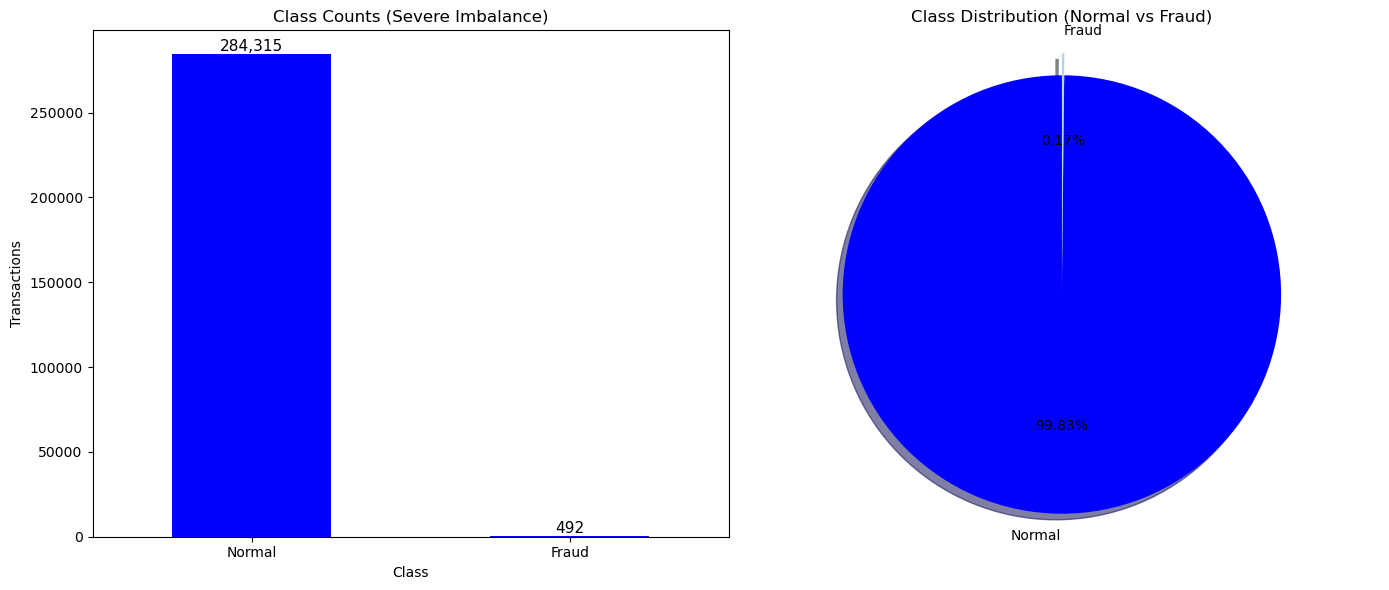

In [11]:
# Counts
counts = df['Class'].value_counts().rename({0:'Normal', 1:'Fraud'})

# Create 1 row, 2 columns
fig, ax = plt.subplots(1, 2, figsize=(14,6))

# --- Bar Plot ---
counts.plot(kind='bar', ax=ax[0], color='blue')  # bar color
for i, v in enumerate(counts.values):
    ax[0].text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=11)

ax[0].set_title('Class Counts (Severe Imbalance)')
ax[0].set_ylabel('Transactions')
ax[0].set_xlabel('Class')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

# --- Pie Chart ---
ax[1].pie(counts.values,
          labels=counts.index,
          autopct='%1.2f%%',
          startangle=90,
          explode=[0,0.1],
          shadow=True,
          colors=['blue','lightblue'])  # pie colors

ax[1].set_title('Class Distribution (Normal vs Fraud)')
ax[1].axis('equal')

plt.tight_layout()
plt.show()

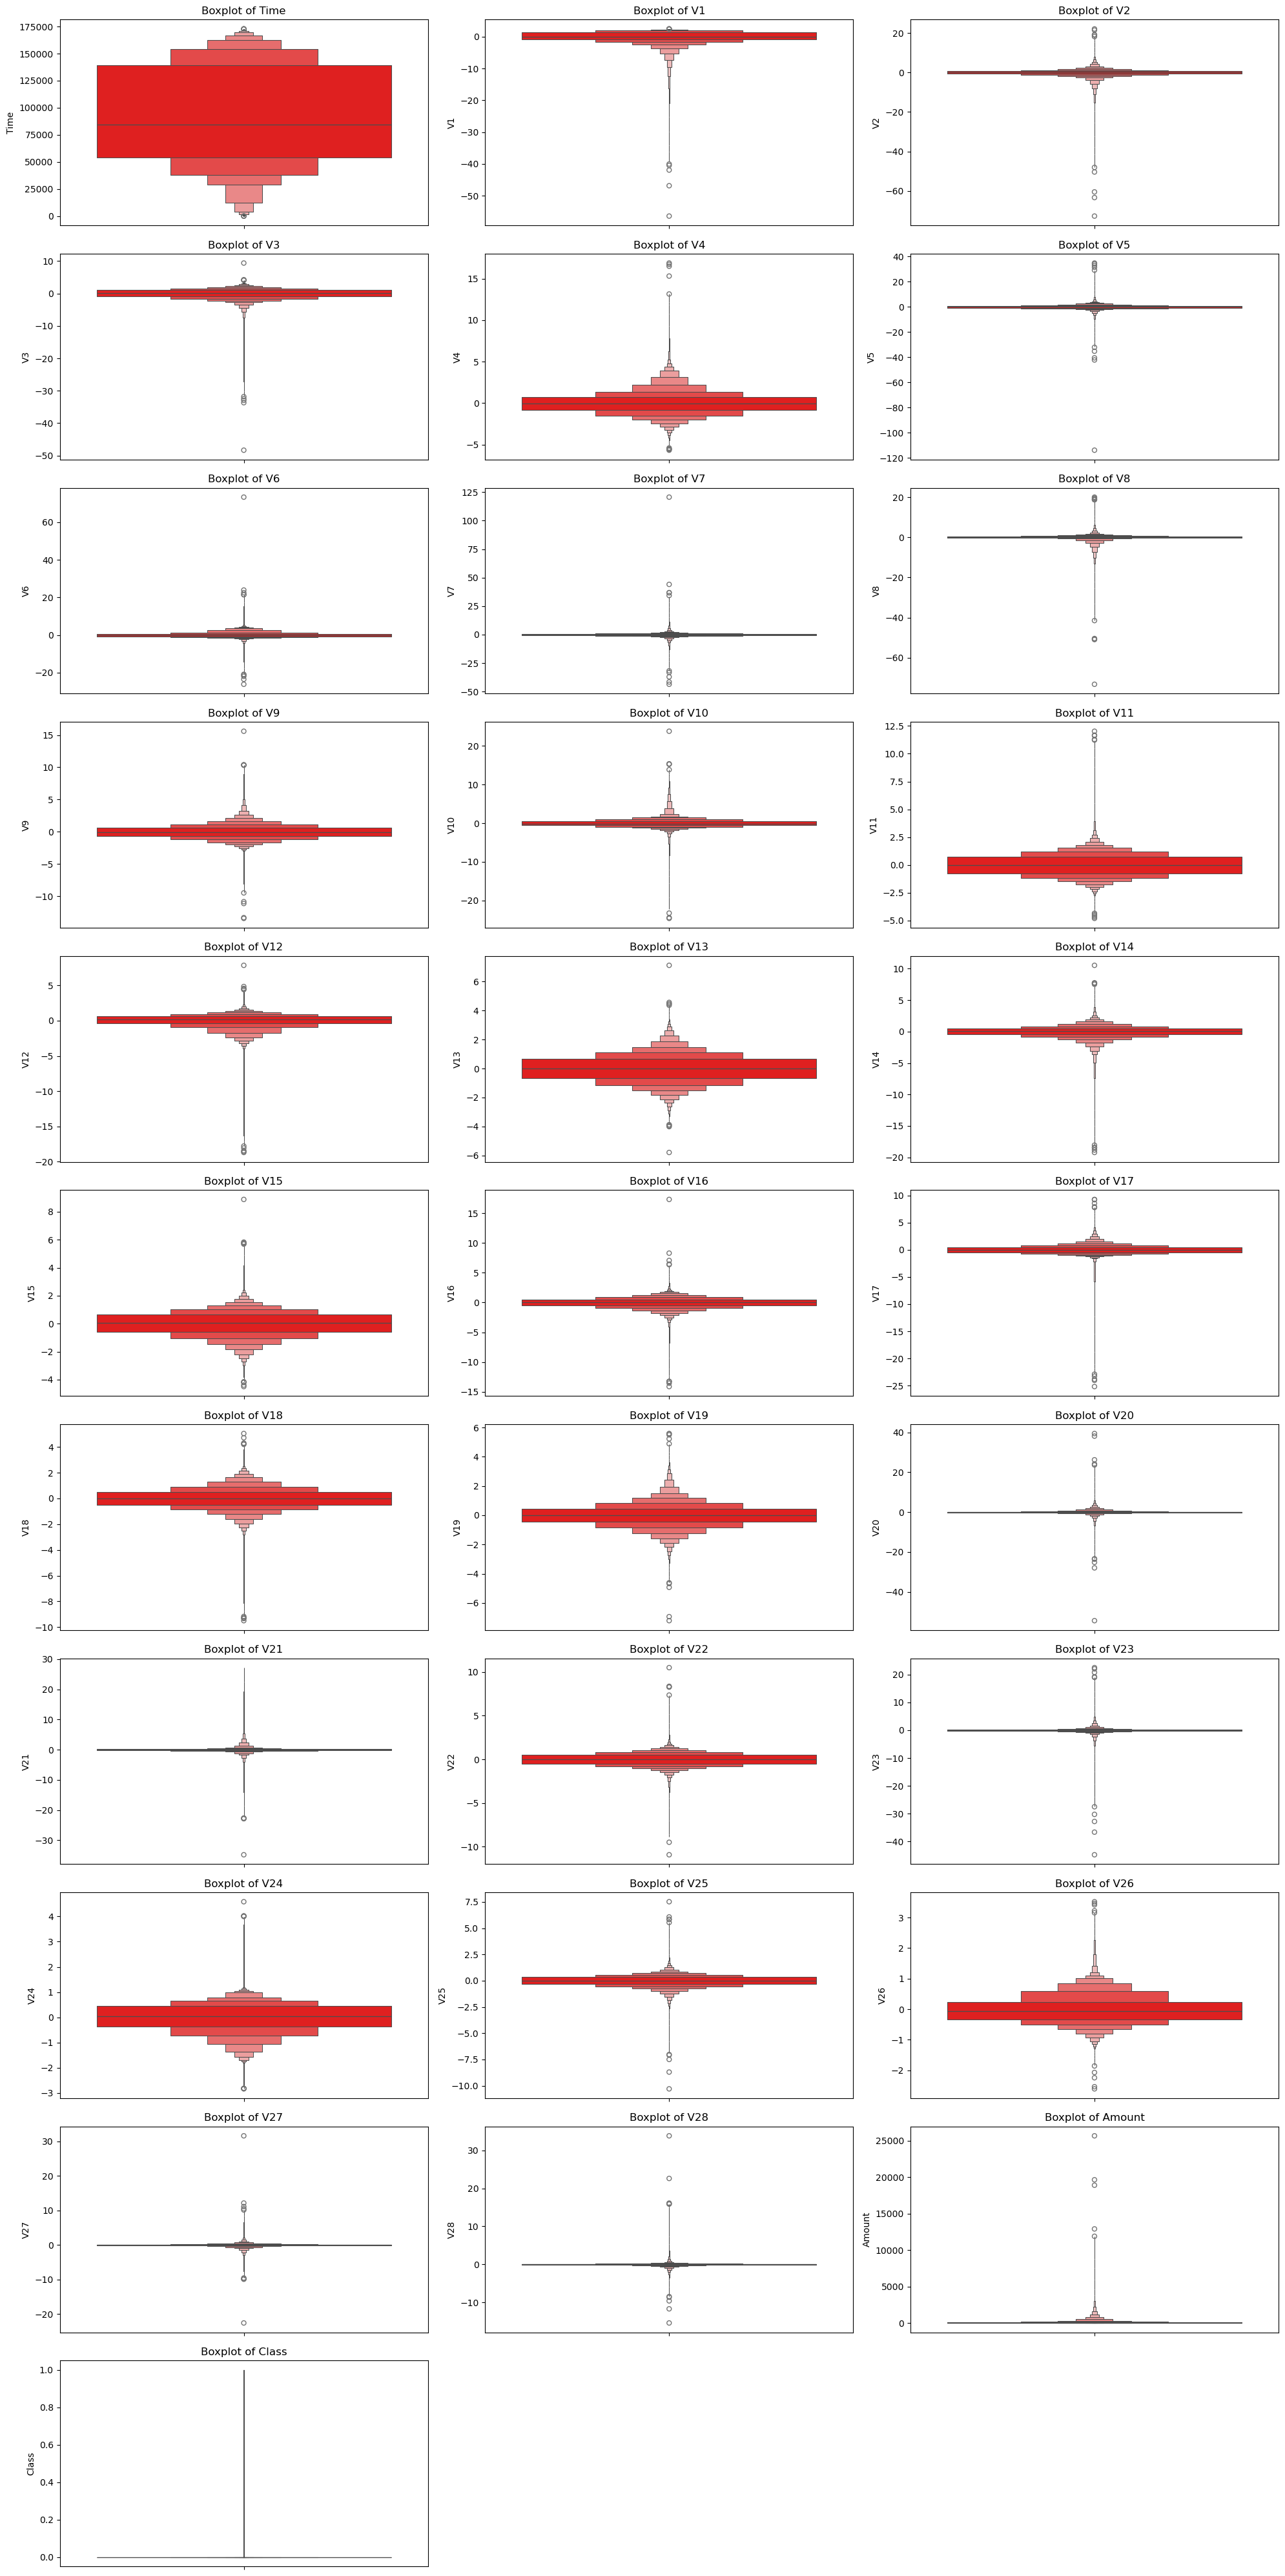

In [12]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(20, 40))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols)//3 + 1, 3, i)
    sns.boxenplot(y=df[col], color="red")
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

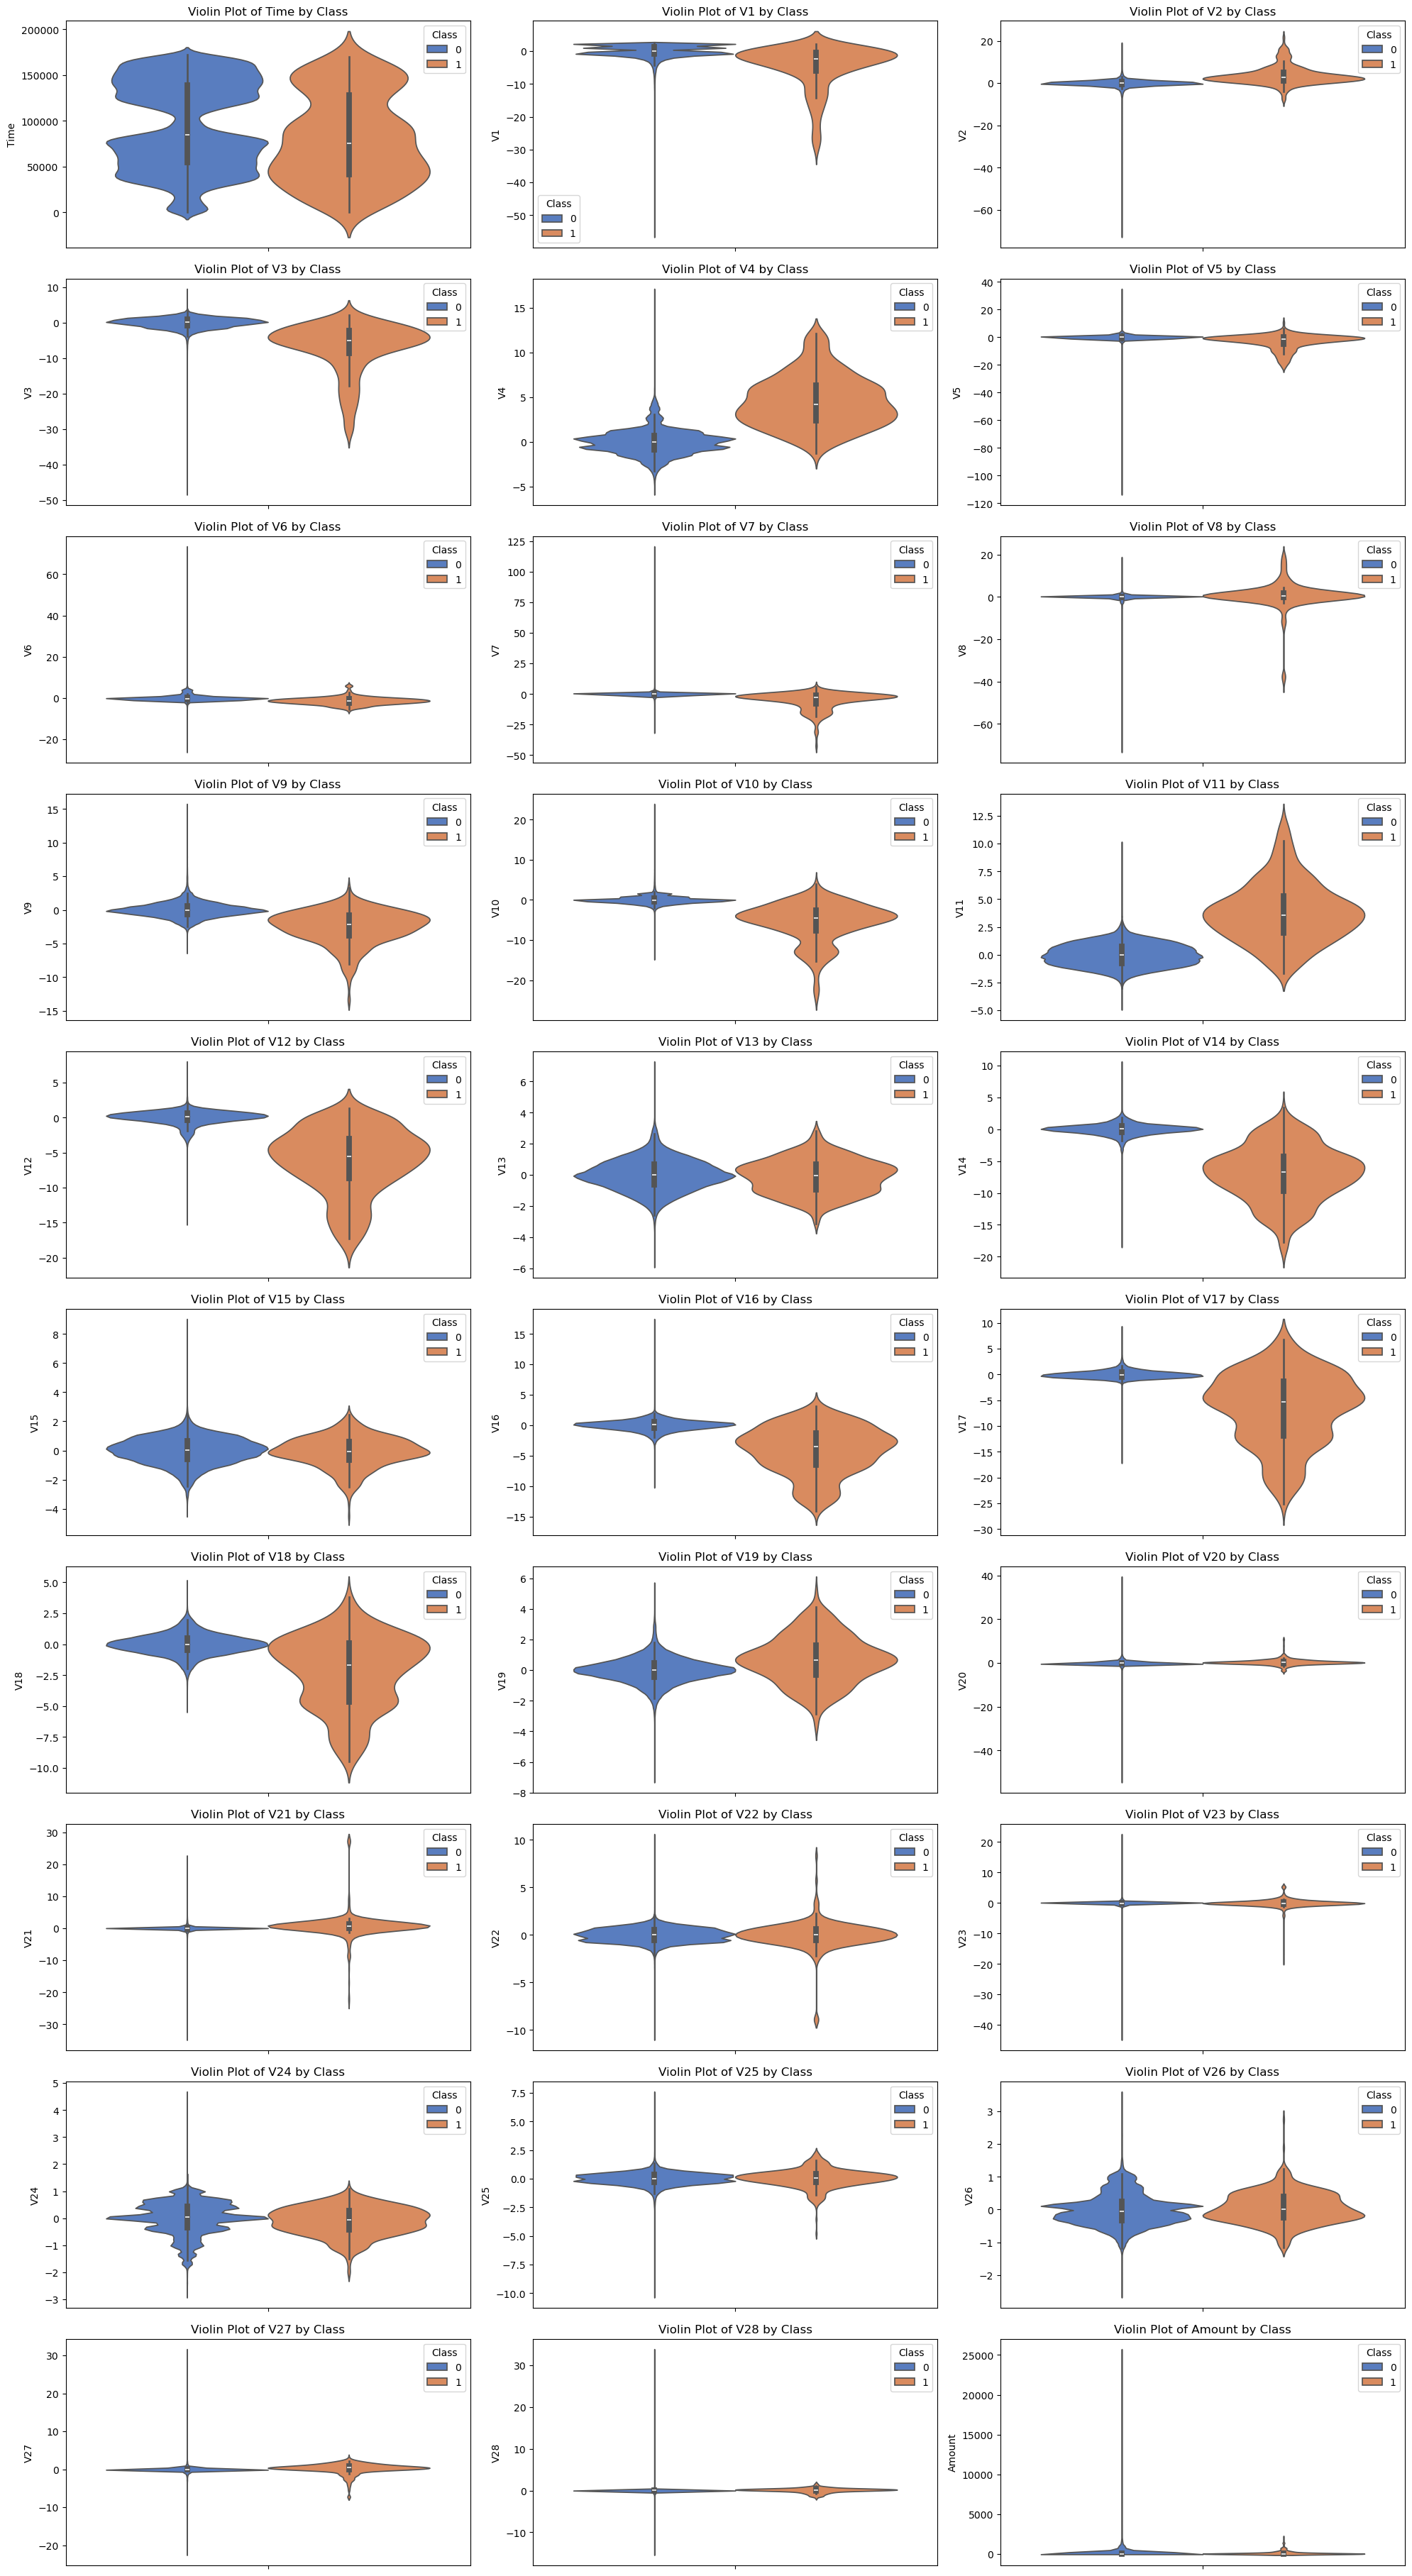

In [13]:
plt.figure(figsize=(20, 40))

for i, col in enumerate(numeric_cols, 1):
    if col != "Class":
        plt.subplot(len(numeric_cols)//3 + 1, 3, i)
        sns.violinplot(data=df, hue="Class", y=col, palette="muted")
        plt.title(f"Violin Plot of {col} by Class")

plt.tight_layout()
plt.show()

In [14]:
df['Time'].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [15]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

## CREATING BOOTSTRAPING FUNCTION

In [16]:
# Bootstrap resampling
def bootstrap_comparison(data, n_boot=1000, random_state=random_state, bins_orig=100, bins_boot=50):
    """
    Compare original distribution vs bootstrap distribution of the mean.
    
    Parameters
    ----------
    data : array-like (Series, ndarray)
        Input data (e.g., df["Time"])
    n_boot : int, default=1000
        Number of bootstrap resamples
    random_state : int, default=42
        Seed for reproducibility
    bins_orig : int, default=100
        Number of bins for original distribution histogram
    bins_boot : int, default=50
        Number of bins for bootstrap distribution histogram
    """
    
    rng = np.random.default_rng(seed=random_state)
    data = np.asarray(data)

    # Bootstrap resampling
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=len(data), replace=True)
        boot_means[i] = sample.mean()

    # --- Summary statistics ---
    # Original distribution
    orig_mean = data.mean()
    orig_std = data.std()
    orig_median = np.median(data)
    orig_mode = stats.mode(data, keepdims=True)[0][0]
    orig_ci_lower, orig_ci_upper = np.percentile(data, [2.5, 97.5])

    # Bootstrap distribution
    boot_mean = boot_means.mean()
    boot_std = boot_means.std()
    boot_median = np.median(boot_means)
    boot_mode = stats.mode(boot_means, keepdims=True)[0][0]
    boot_ci_lower, boot_ci_upper = np.percentile(boot_means, [2.5, 97.5])

    # --- Plot side by side ---
    fig, ax = plt.subplots(1, 2, figsize=(14,6))

    # Original distribution
    sns.histplot(data, bins=bins_orig, kde=True, color="green", ax=ax[0])
    ax[0].set_title("Distribution of Original Data")
    ax[0].set_xlabel("Value")
    ax[0].set_ylabel("Frequency")
    ax[0].axvline(orig_mean, color="red", linestyle="--", label=f"Mean = {orig_mean:.2f}")
    ax[0].axvline(orig_median, color="green", linestyle="--", label=f"Median = {orig_median:.2f}")
    ax[0].axvline(orig_mode, color="purple", linestyle="--", label=f"Mode = {orig_mode:.2f}")
    ax[0].axvline(orig_ci_lower, color="orange", linestyle=":", label=f"95% CI Lower = {orig_ci_lower:.2f}")
    ax[0].axvline(orig_ci_upper, color="orange", linestyle=":", label=f"95% CI Upper = {orig_ci_upper:.2f}")
    ax[0].legend()

    # Bootstrap distribution
    sns.histplot(boot_means, bins=bins_boot, kde=True, color="blue", ax=ax[1])
    ax[1].set_title("Bootstrap Distribution of Mean")
    ax[1].set_xlabel("Mean Value")
    ax[1].set_ylabel("Frequency")
    ax[1].axvline(boot_mean, color="red", linestyle="--", label=f"Mean = {boot_mean:.2f}")
    ax[1].axvline(boot_median, color="green", linestyle="--", label=f"Median = {boot_median:.2f}")
    ax[1].axvline(boot_mode, color="purple", linestyle="--", label=f"Mode = {boot_mode:.2f}")
    ax[1].axvline(boot_ci_lower, color="orange", linestyle=":", label=f"95% CI Lower = {boot_ci_lower:.2f}")
    ax[1].axvline(boot_ci_upper, color="orange", linestyle=":", label=f"95% CI Upper = {boot_ci_upper:.2f}")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

# TIME DISTRIBUTION

============================================================ Time Distribution ============================================================


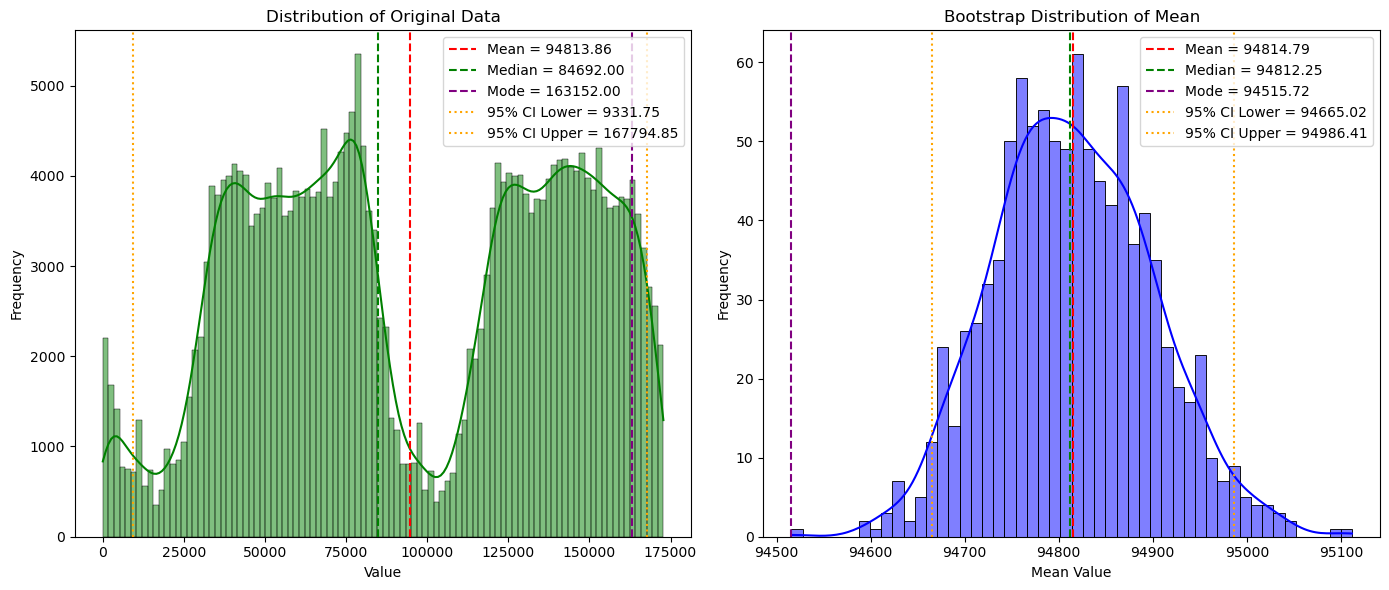

In [17]:
print("="*60, "Time Distribution","="*60)
bootstrap_comparison(df["Time"], n_boot=1000, random_state=random_state, bins_orig=100, bins_boot=50)

In [18]:
def skewness(col):
    # If it's a pandas Series, use .skew(); if ndarray, use scipy
    if hasattr(col, "skew"):  
        skew_val = col.skew()
    else:
        skew_val = skew(col)

    if skew_val > 1:
        interpretation = "Highly right skewed"
    elif 0.5 < skew_val <= 1:
        interpretation = "Moderately right skewed"
    elif -0.5 <= skew_val <= 0.5:
        interpretation = "Approximately symmetric"
    elif -1 <= skew_val < -0.5:
        interpretation = "Moderately left skewed"
    else:
        interpretation = "Highly left skewed"
    return f"Skewness: {skew_val:.4f} → {interpretation}"

def kurtosis_val(col):
    # pandas Series has .kurt(); ndarray needs scipy.kurtosis
    if hasattr(col, "kurt"):
        kurt_val = col.kurt()
    else:
        kurt_val = kurtosis(col, fisher=False)  # Pearson definition (normal=3)

    if kurt_val > 3:
        interpretation = "Leptokurtic (heavy tails, more outliers)"
    elif kurt_val < 3:
        interpretation = "Platykurtic (light tails, fewer outliers)"
    else:
        interpretation = "Mesokurtic (close to normal)"
    return f"Kurtosis: {kurt_val:.4f} → {interpretation}"

def d_agostino_normality(col):
    # Shapiro-Wilk test
    stat, p = normaltest(col)
    interpretation = "Data looks normally distributed (fail to reject H0)" if p > 0.05 else "Data is not normally distributed (reject H0)"
    return f"D'Agostino-Pearson p-value: {p:.4f} → {interpretation}"

def ks_normality(col):
    # Shapiro-Wilk test
    stat, p = normaltest(col)
    interpretation = "Data looks normally distributed (fail to reject H0)" if p > 0.05 else "Data is not normally distributed (reject H0)"
    return f"Kolmogorov-Smirnov p-value: {p:.4f} → {interpretation}"

In [19]:
data = df["Time"].values
original_col = data
rng = np.random.default_rng(seed=random_state)

boot_means = []
for i in range(1000):
    sample = rng.choice(data, size=len(data), replace=True)
    boot_means.append(sample.mean())

bootstrap_col = boot_means

In [20]:
print(kurtosis_val(original_col))
print(kurtosis_val(bootstrap_col))

Kurtosis: 1.7065 → Platykurtic (light tails, fewer outliers)
Kurtosis: 2.9742 → Platykurtic (light tails, fewer outliers)


In [21]:
print(d_agostino_normality(original_col))
print(d_agostino_normality(bootstrap_col))

D'Agostino-Pearson p-value: 0.0000 → Data is not normally distributed (reject H0)
D'Agostino-Pearson p-value: 0.1610 → Data looks normally distributed (fail to reject H0)


In [22]:
print(ks_normality(original_col))
print(ks_normality(bootstrap_col))

Kolmogorov-Smirnov p-value: 0.0000 → Data is not normally distributed (reject H0)
Kolmogorov-Smirnov p-value: 0.1610 → Data looks normally distributed (fail to reject H0)


# AMOUNT DISTRIBUTION

============================================================ Amount Distribution ============================================================


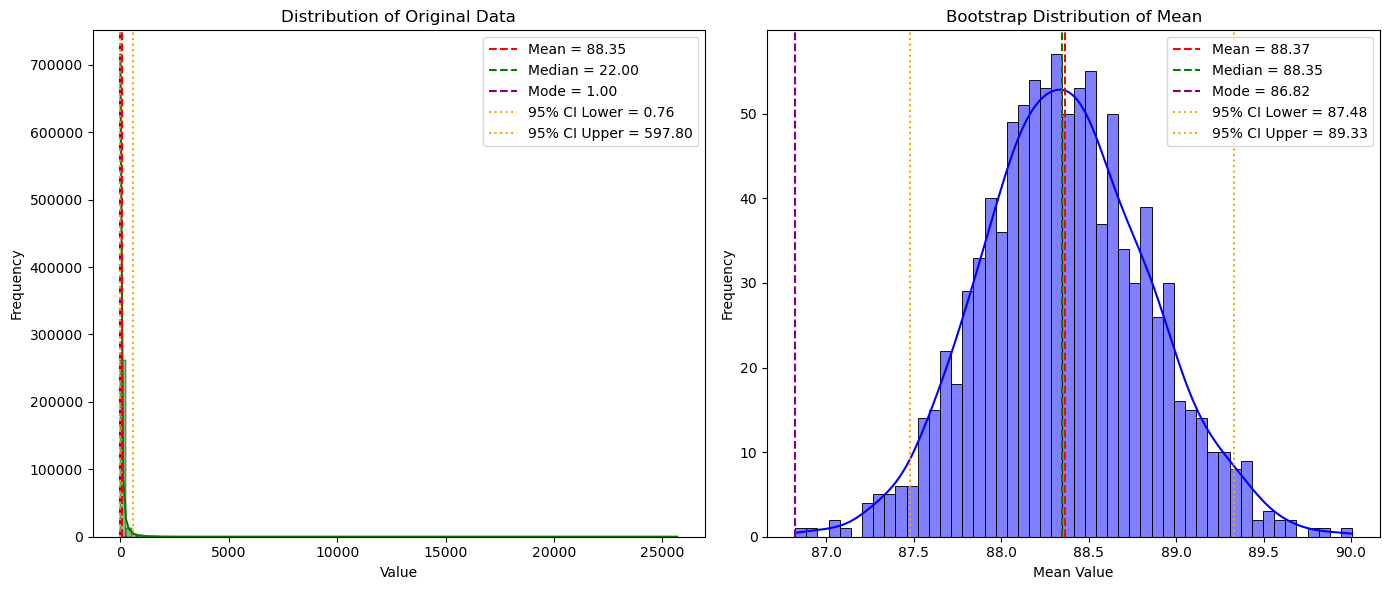

In [23]:
print("="*60, "Amount Distribution","="*60)
bootstrap_comparison(df["Amount"], n_boot=1000, random_state=random_state, bins_orig=100, bins_boot=50)

In [24]:
data = df["Amount"]

# Bootstrap resampling
rng = np.random.default_rng(seed=random_state)
n_boot = 1000
boot_means = np.empty(n_boot)

for i in range(n_boot):
    sample = rng.choice(data, size=len(data), replace=True)
    boot_means[i] = sample.mean()

# Now compare original vs bootstrap
original_col = data
bootstrap_col = boot_means

print(skewness(original_col))
print(skewness(bootstrap_col))
print(kurtosis_val(original_col))
print(kurtosis_val(bootstrap_col))
print(d_agostino_normality(original_col))
print(d_agostino_normality(bootstrap_col))
print(ks_normality(original_col))
print(ks_normality(bootstrap_col))

Skewness: 16.9777 → Highly right skewed
Skewness: 0.1092 → Approximately symmetric
Kurtosis: 845.0926 → Leptokurtic (heavy tails, more outliers)
Kurtosis: 3.0642 → Leptokurtic (heavy tails, more outliers)
D'Agostino-Pearson p-value: 0.0000 → Data is not normally distributed (reject H0)
D'Agostino-Pearson p-value: 0.3206 → Data looks normally distributed (fail to reject H0)
Kolmogorov-Smirnov p-value: 0.0000 → Data is not normally distributed (reject H0)
Kolmogorov-Smirnov p-value: 0.3206 → Data looks normally distributed (fail to reject H0)


# Feature Engineering

In [25]:
df['Hour_from_start_mod24'] = ((df['Time'] // 3600) % 24).astype(int)
df['is_night'] = df['Hour_from_start_mod24'].isin([22,23,0,1,2,3,4,5]).astype(int)
df['is_business_hour'] = df['Hour_from_start_mod24'].between(9,17).astype(int)
df["Time_Sin"] = np.sin(2 * np.pi * df["Time"] / 24)
df["Time_Cos"] = np.cos(2 * np.pi * df["Time"] / 24)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V26,V27,V28,Amount,Class,Hour_from_start_mod24,is_night,is_business_hour,Time_Sin,Time_Cos
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.189115,0.133558,-0.021053,149.62,0,0,1,0,0.000000,1.000000
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.125895,-0.008983,0.014724,2.69,0,0,1,0,0.000000,1.000000
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.139097,-0.055353,-0.059752,378.66,0,0,1,0,0.258819,0.965926
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.221929,0.062723,0.061458,123.50,0,0,1,0,0.258819,0.965926
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.502292,0.219422,0.215153,69.99,0,0,1,0,0.500000,0.866025


In [26]:
pd.DataFrame(df.groupby("Class")["Hour_from_start_mod24"].value_counts())

count
Class Hour_from_start_mod24       
0     21                     17687
      18                     17006
      11                     16803
      20                     16738
      10                     16590
      14                     16547
      15                     16435
      16                     16431
      17                     16137
      9                      15822
      19                     15630
      22                     15432
      12                     15403
      13                     15348
      23                     10917
      8                      10267
      0                       7689
      7                       7220
      1                       4210
      6                       4092
      3                       3475
      2                       3271
      5                       2979
      4                       2186
1     2                         57
      11                        53
      18                        33
      17                        29
      15                        26
      7                         23
      4                         23
      14                        23
      16                        22
      23                        21
      19                        19
      20                        18
      3                         17
      12                        17
      13                        17
      9                         16
      21                        16
      5                         11
      1                         10
      6                          9
      8                          9
      22                         9
      10                         8
      0                          6

Note: 2 hours after first transaction has the most time for fraudulent transactions

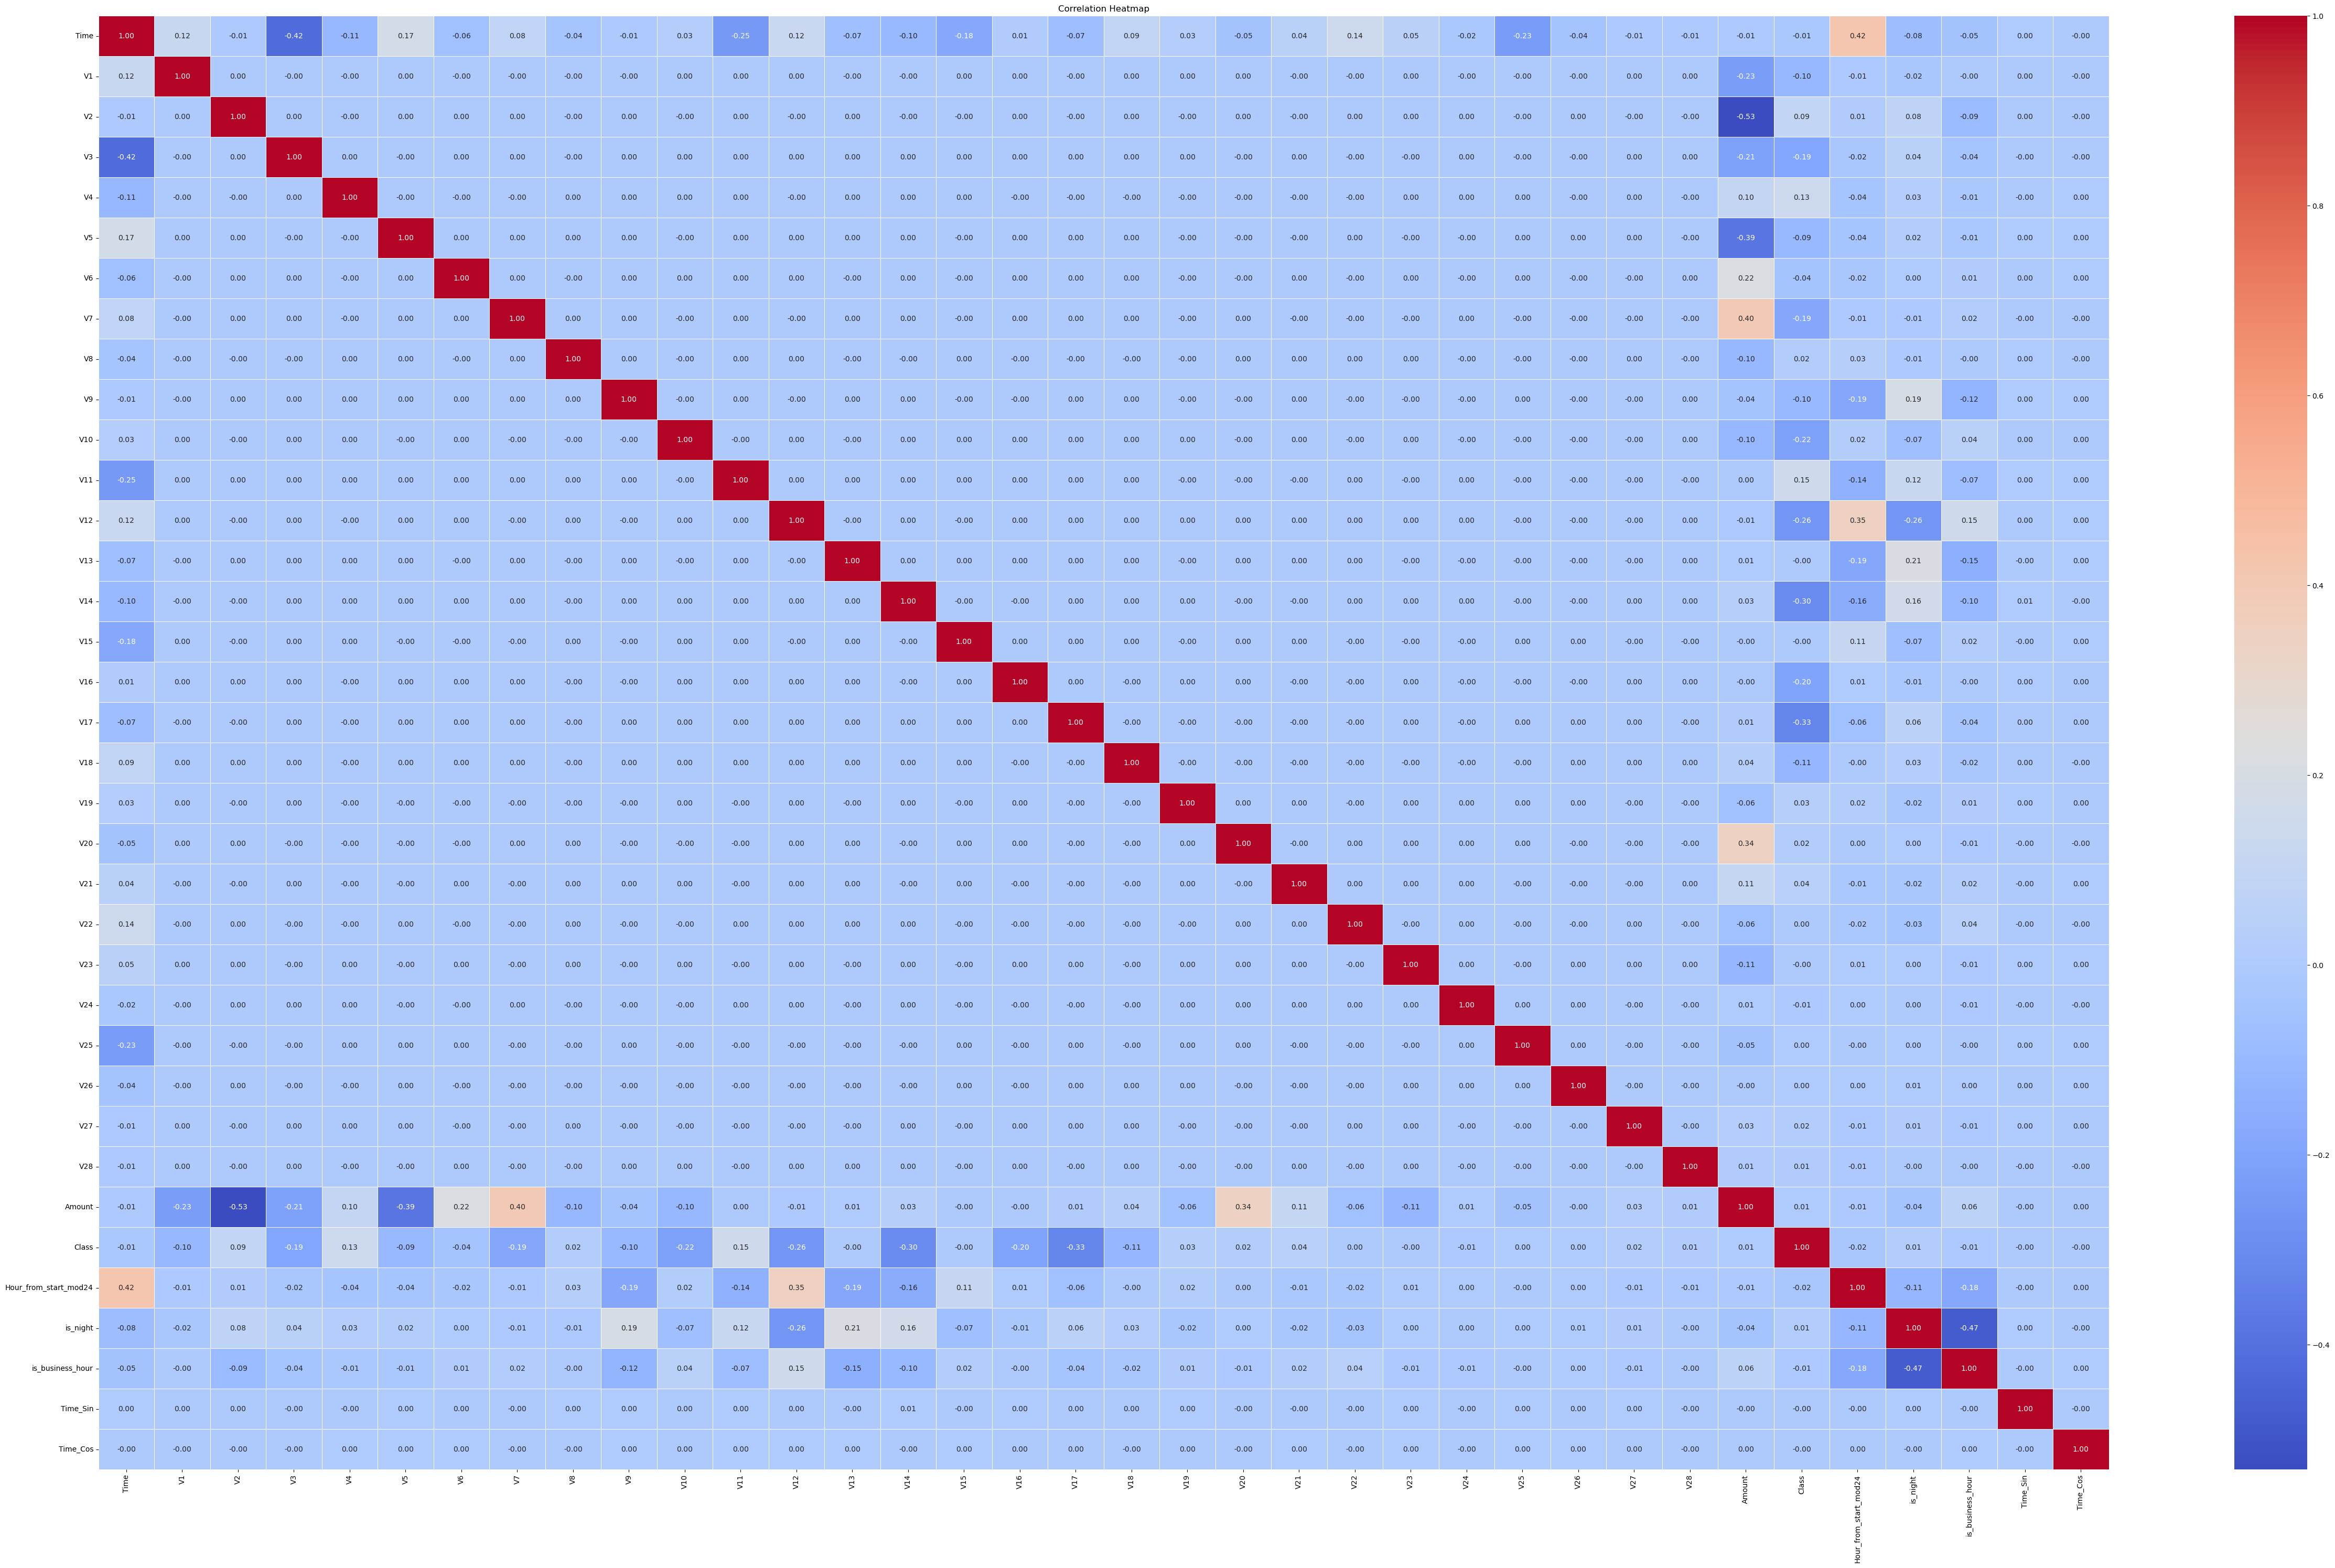

In [27]:
corr = df.corr()
plt.figure(figsize=(50,30))
sns.heatmap(corr, cmap="coolwarm", annot=True, linewidths=0.5, fmt="0.2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

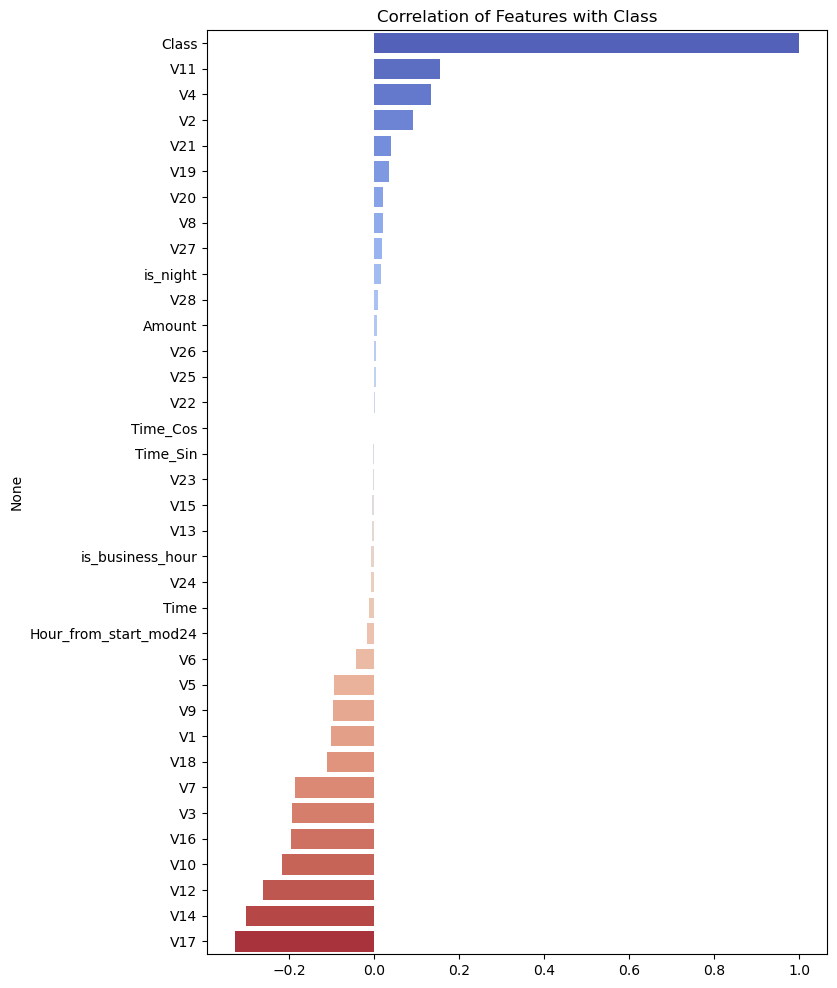

In [28]:
class_corr = df.corr()["Class"].sort_values(ascending=False)

plt.figure(figsize=(8,12))
sns.barplot(
    x=class_corr.values,        # 1D array of correlation values
    y=class_corr.index,         # feature names
    hue=class_corr.index,       # assign y variable to hue
    palette="coolwarm",
    legend=False
)
plt.title("Correlation of Features with Class")
plt.show()

# Weaker Correlations

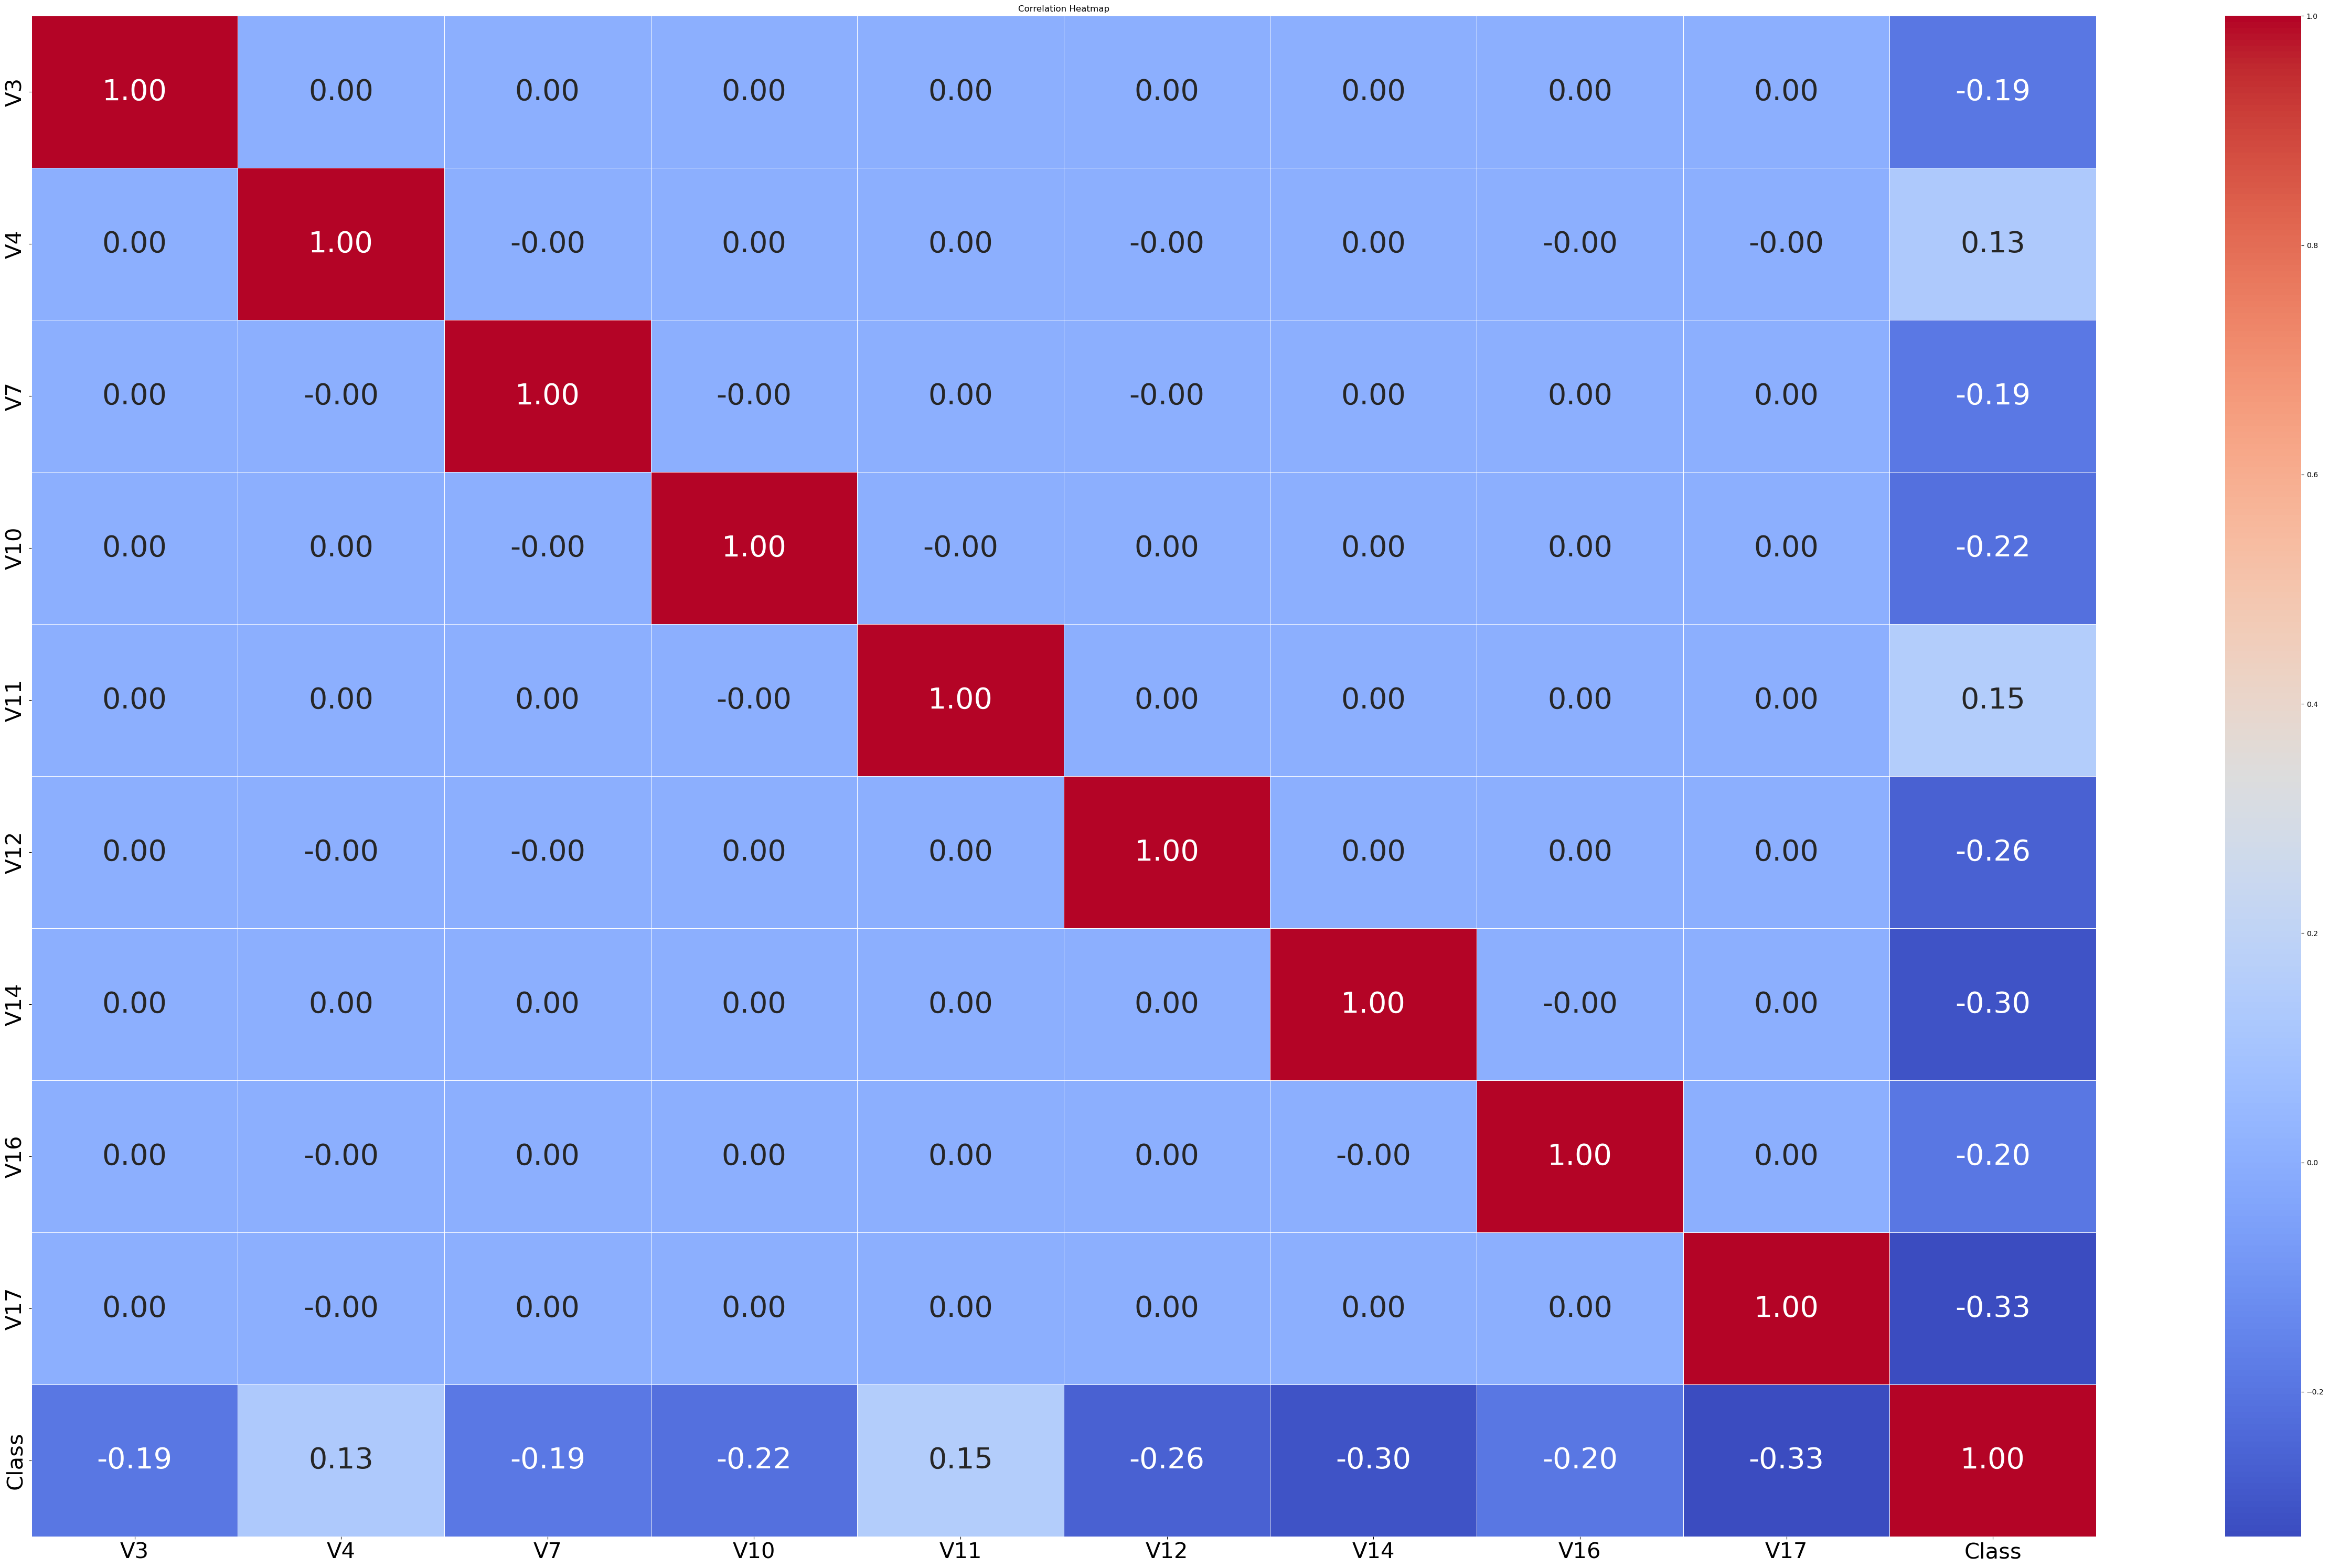

In [29]:
df_copy = df.copy()

# Drop columns with weak correlation to "Class"
class_corr = df_copy.corr()["Class"]
for column, corr_val in class_corr.items():
    if abs(corr_val) < 0.13:
        df_copy.drop(columns=column, inplace=True)

# Recompute correlation matrix after dropping
corr = df_copy.corr()

# Plot heatmap
plt.figure(figsize=(50,30))
plt.xticks(fontsize=30) 
plt.yticks(fontsize=30)
sns.heatmap(corr, cmap="coolwarm", annot=True, linewidths=0.5, fmt=".2f", annot_kws={"size": 40})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Stronger Correlations

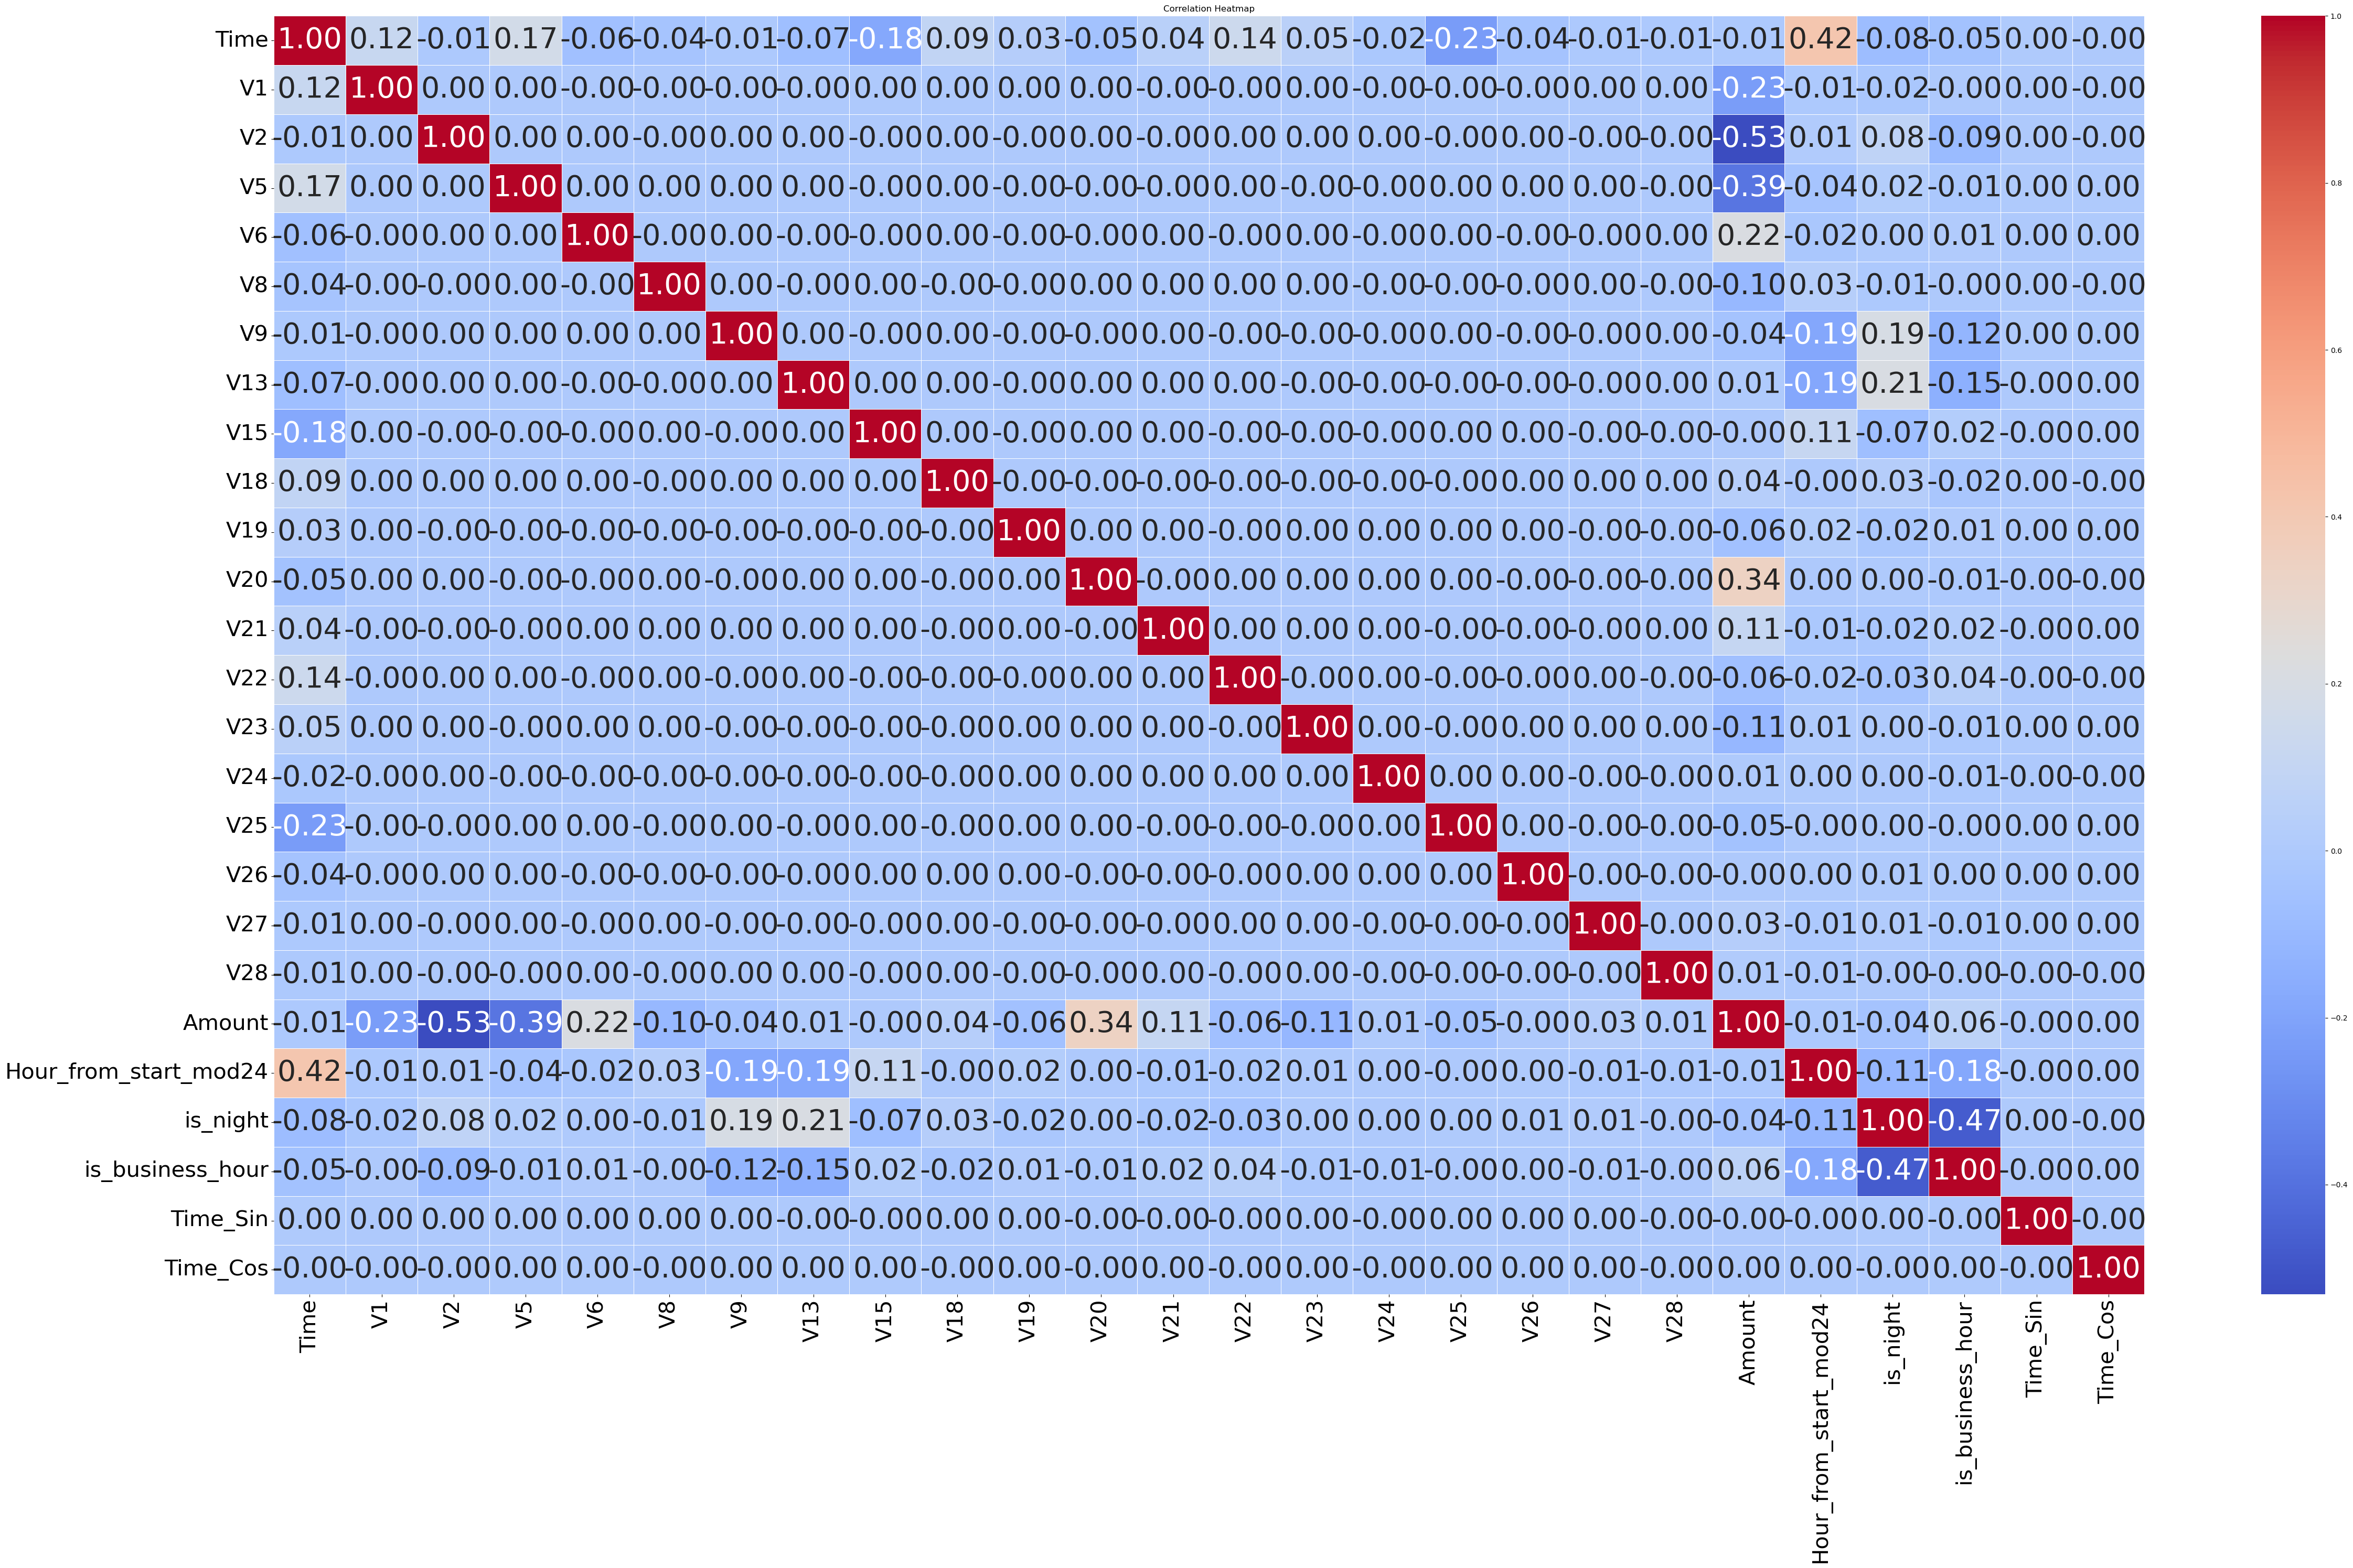

In [30]:
df_copy = df.copy()

# Drop columns with weak correlation to "Class"
class_corr = df_copy.corr()["Class"]
for column, corr_val in class_corr.items():
    if abs(corr_val) > 0.13:
        df_copy.drop(columns=column, inplace=True)

# Recompute correlation matrix after dropping
corr = df_copy.corr()

# Plot heatmap
plt.figure(figsize=(50,30))
plt.xticks(fontsize=30) 
plt.yticks(fontsize=30)
sns.heatmap(corr, cmap="coolwarm", annot=True, linewidths=0.5, fmt=".2f", annot_kws={"size": 40})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [50]:
# splitting the data to apply different techniques of handling imbalance data on training set.
X = df.drop(columns = ['Class']).astype("float32")
y = df['Class']

In [32]:
sss = StratifiedShuffleSplit(n_splits=n_split, test_size=0.2, random_state=random_state)
stkf = StratifiedKFold(n_splits=n_split, shuffle=True, random_state=random_state)

for train_index, test_index in sss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
print(f'Stratfied Shuffle Split: shape of X_train is {X_train.shape}, shape of X_test is {X_test.shape}, shape of y_train is {y_train.shape}, shape of y_test is {y_test.shape}')

for train_index, test_index in stkf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
print(f'Stratfied KFold Split: shape of X_train is {X_train.shape}, shape of X_test is {X_test.shape}, shape of y_train is {y_train.shape}, shape of y_test is {y_test.shape}')

Stratfied Shuffle Split: shape of X_train is (227845, 35), shape of X_test is (56962, 35), shape of y_train is (227845,), shape of y_test is (56962,)
Stratfied KFold Split: shape of X_train is (227846, 35), shape of X_test is (56961, 35), shape of y_train is (227846,), shape of y_test is (56961,)


# Here are the 3 of the most common UnderSampling Methods when dealing with Imbalanced Dataset

1. RandomUnderSampler - Randomly removes samples from the majority class until balance is achieved.
2. SMOTE (Synthetic Minority Oversampling Technique) - Generates synthetic samples for the minority class by interpolating between neighbors.
3. SMOTE‑Tomek - Combines SMOTE oversampling with Tomek links (removes borderline samples where classes overlap).

# Practical Applications
- If your dataset is large → start with RandomUnderSampler (quick, efficient).
- If your dataset is small or minority class is tiny → use SMOTE to generate synthetic samples.
- If your dataset has class overlap/noisy boundaries → use SMOTE‑Tomek for both balancing and cleaning.

On this dataset which is large - 284 thousand rows, we'll use SMOTE-Tomek Undersampling

# TRAINING WITHOUT RESAMPLING

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% test, 80% train
    stratify=y,           # preserve class ratios
    random_state=random_state     
)

models = {
    "ExtraTreesClassifier": ExtraTreesClassifier(),
    # "LabelPropagation": LabelPropagation(),
    # "LabelSpreading": LabelSpreading(),
    "LGBMClassifier": LGBMClassifier(),
    "LinearSVC": LinearSVC(),
    "CalibratedClassifierCV": CalibratedClassifierCV(),
    "RandomForestClassifier": RandomForestClassifier(),
    "SGDClassifier": SGDClassifier(),
    "LogisticRegression": LogisticRegression(),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "Perceptron": Perceptron(),
    # "QuadraticDiscriminantAnalysis": QuadraticDiscriminantAnalysis(),
    # "SVC": SVC(),
    "GaussianNB": GaussianNB(),
    "BernoulliNB": BernoulliNB(),
    "XGBClassifier": XGBClassifier(),
    "CatBoostClassifier": CatBoostClassifier(),
    "AdaBoostClassifier": AdaBoostClassifier(),
    "BaggingClassifier": BaggingClassifier(),
    "NuSVC": NuSVC(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "RidgeClassifier": RidgeClassifier(),
    "LinearDiscriminantAnalysis": LinearDiscriminantAnalysis(),
    "ExtraTreeClassifier": ExtraTreeClassifier(),
    "NearestCentroid": NearestCentroid(),
    "RidgeClassifierCV": RidgeClassifierCV(),
    "PassiveAggressiveClassifier": PassiveAggressiveClassifier(),
    "DummyClassifier": DummyClassifier()
}

results = {
    "Model": [],
    "Accuracy": [],
    "F1 Score Weighted": [],
    "F1 Score Macro": [],
    "Precision_weighted": [],
    "Recall_weighted": [],
    "Precision_macro_avg": [],
    "Recall_macro_avg": []
}

for model_name, model in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    results["Model"].append(model_name)
    results["Accuracy"].append(accuracy_score(y_test, y_pred))
    results["F1 Score Weighted"].append(f1_score(y_test, y_pred, average='weighted'))
    results["F1 Score Macro"].append(f1_score(y_test, y_pred, average='macro'))
    results["Precision_weighted"].append(precision_score(y_test, y_pred, average='weighted'))
    results["Recall_weighted"].append(recall_score(y_test, y_pred, average='weighted'))
    results["Precision_macro_avg"].append(precision_score(y_test, y_pred, average='macro'))
    results["Recall_macro_avg"].append(recall_score(y_test, y_pred, average='macro'))

results_df = pd.DataFrame(results)

C:\Users\kenne\miniconda3\envs\torch-gpu_p3.12\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7709
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339


C:\Users\kenne\miniconda3\envs\torch-gpu_p3.12\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\kenne\miniconda3\envs\torch-gpu_p3.12\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Learning rate set to 0.104628
0:	learn: 0.3828703	total: 183ms	remaining: 3m 3s
1:	learn: 0.2000560	total: 213ms	remaining: 1m 46s
2:	learn: 0.1078074	total: 242ms	remaining: 1m 20s
3:	learn: 0.0584860	total: 282ms	remaining: 1m 10s
4:	learn: 0.0338699	total: 311ms	remaining: 1m 1s
5:	learn: 0.0210548	total: 339ms	remaining: 56.1s
6:	learn: 0.0140078	total: 364ms	remaining: 51.7s
7:	learn: 0.0099126	total: 388ms	remaining: 48.2s
8:	learn: 0.0074787	total: 419ms	remaining: 46.1s
9:	learn: 0.0060003	total: 445ms	remaining: 44.1s
10:	learn: 0.0050519	total: 478ms	remaining: 43s
11:	learn: 0.0043514	total: 508ms	remaining: 41.8s
12:	learn: 0.0038517	total: 543ms	remaining: 41.3s
13:	learn: 0.0035336	total: 568ms	remaining: 40s
14:	learn: 0.0033041	total: 597ms	remaining: 39.2s
15:	learn: 0.0031355	total: 623ms	remaining: 38.3s
16:	learn: 0.0029696	total: 655ms	remaining: 37.9s
17:	learn: 0.0028451	total: 683ms	remaining: 37.3s
18:	learn: 0.0027553	total: 712ms	remaining: 36.8s
19:	learn: 0

AttributeError: The following error was raised: 'CatBoostClassifier' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.